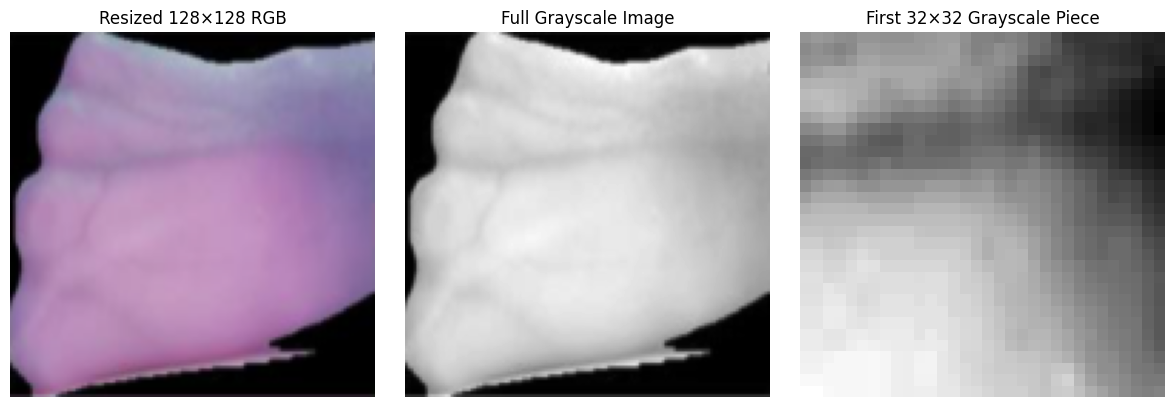

Resized RGB shape: (128, 128, 3)
Full grayscale shape: (128, 128)
First grayscale piece shape: (32, 32)
Saved gray_o.txt successfully.


In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ---- Load and resize to 128x128 ----
img = Image.open("NIR_vein.png").convert("RGB")
img_128 = img.resize((128, 128), Image.BILINEAR)
img_128_np = np.array(img_128)

# ---- Break into 16 pieces (each 32x32) ----
pieces = []
for i in range(4):       # 4 rows
    for j in range(4):   # 4 columns
        piece = img_128_np[i*32:(i+1)*32, j*32:(j+1)*32, :]
        pieces.append(piece)

# First 32×32 piece
first_piece_rgb = pieces[6]

# ---- Convert full resized image to grayscale ----
gray_full = np.dot(img_128_np[..., :3], [0.2989, 0.5870, 0.1140])

# ---- Convert first piece to grayscale ----
first_piece_gray = np.dot(first_piece_rgb[..., :3], [0.2989, 0.5870, 0.1140])

# ---- Save first piece as gray_o.txt ----
np.savetxt("gray_o.txt", first_piece_gray, fmt="%.4f")

# ---- Load grayscale piece back from txt ----
first_piece_gray_loaded = np.loadtxt("gray_o.txt")

# ---- Display: resized RGB, full grayscale, first piece grayscale ----
plt.figure(figsize=(12,4))

plt.subplot(1, 3, 1)
plt.imshow(img_128_np)
plt.title("Resized 128×128 RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_full, cmap="gray")
plt.title("Full Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(first_piece_gray_loaded, cmap="gray")
plt.title("First 32×32 Grayscale Piece")
plt.axis("off")

plt.tight_layout()
plt.show()

# ---- Info ----
print("Resized RGB shape:", img_128_np.shape)
print("Full grayscale shape:", gray_full.shape)
print("First grayscale piece shape:", first_piece_gray_loaded.shape)
print("Saved gray_o.txt successfully.")


In [18]:
# 1. Read the messy floating-point matrix file
try:
    # This automatically handles multiple columns and newlines
    data = np.loadtxt("gray_o.txt") 
    
    # 2. Flatten to 1D array and convert to Integer
    flat_data = data.flatten().astype(int)
    
    # 3. Save as a simple list (one number per line)
    np.savetxt("gray_o_clean.txt", flat_data, fmt='%d')
    
    print(f"Success! Converted {len(flat_data)} pixels.")
    print("Update your VHDL testbench to read 'gray_o_clean.txt'")
    
except Exception as e:
    print(f"Error processing file: {e}")

Success! Converted 1024 pixels.
Update your VHDL testbench to read 'gray_o_clean.txt'


Loading clahe_output_image.txt...
Loading clahe_mapping_table.txt...
Loading gray_o_clean.txt...


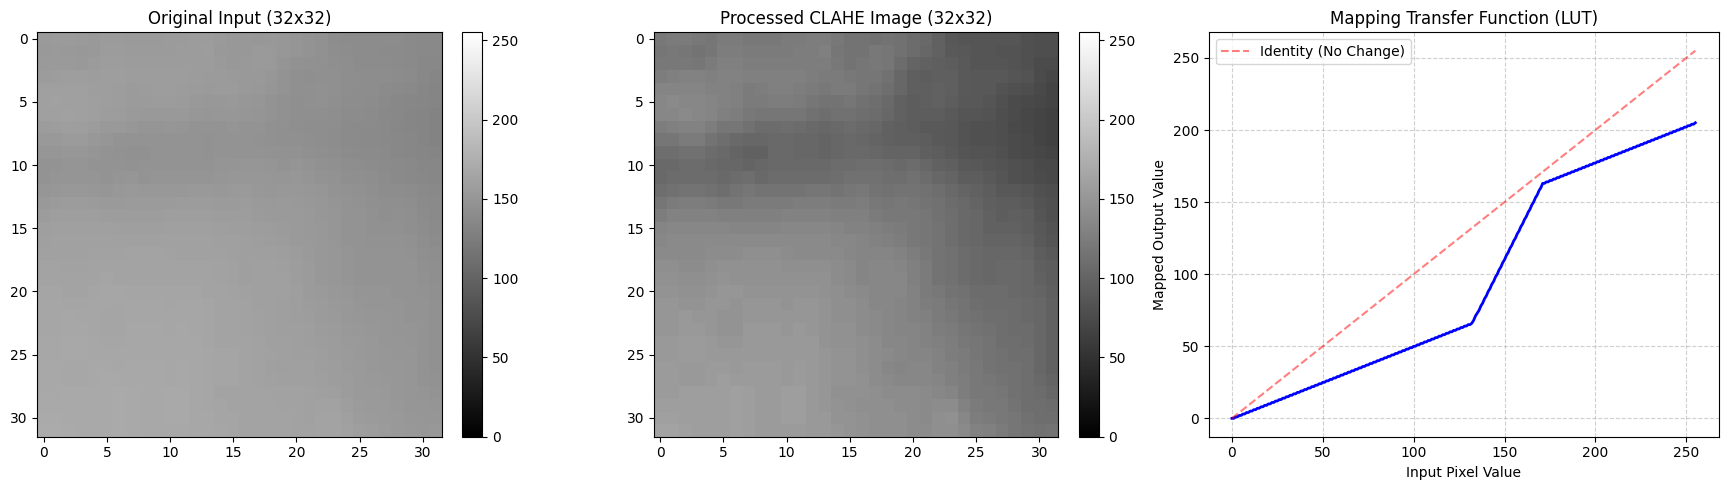

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
# Dimensions must match your VHDL constants (CLAHE_PATCH_X/Y)
WIDTH = 32
HEIGHT = 32

# File paths
IMG_FILE = 'clahe_output_image.txt'
MAP_FILE = 'clahe_mapping_table.txt'
# Updated to point to the clean version
ORIGINAL_FILE = 'gray_o_clean.txt' 
# -----------------------------------------------

def load_and_visualize():
    try:
        # --- 1. Load Data ---
        
        # Load Output Image
        print(f"Loading {IMG_FILE}...")
        raw_img_data = np.loadtxt(IMG_FILE, dtype=int)
        if len(raw_img_data) != WIDTH * HEIGHT:
            print(f"Warning: Expected {WIDTH*HEIGHT} pixels in output, found {len(raw_img_data)}")
        output_image = raw_img_data.reshape((HEIGHT, WIDTH))

        # Load Mapping Table
        print(f"Loading {MAP_FILE}...")
        mapping_table = np.loadtxt(MAP_FILE, dtype=int)

        # Load Original Image (gray_o_clean)
        print(f"Loading {ORIGINAL_FILE}...")
        raw_orig_data = np.loadtxt(ORIGINAL_FILE, dtype=int)
        if len(raw_orig_data) != WIDTH * HEIGHT:
             print(f"Warning: Expected {WIDTH*HEIGHT} pixels in original, found {len(raw_orig_data)}")
        original_image = raw_orig_data.reshape((HEIGHT, WIDTH))

        # --- 2. Setup the Plotting Dashboard (1 Row, 3 Columns) ---
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # --- Left Plot: Original Image ---
        im0 = axes[0].imshow(original_image, cmap='gray', vmin=0, vmax=255)
        axes[0].set_title("Original Input (32x32)")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        # --- Middle Plot: Resulting Image ---
        im1 = axes[1].imshow(output_image, cmap='gray', vmin=0, vmax=255)
        axes[1].set_title("Processed CLAHE Image (32x32)")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        
        # --- Right Plot: The Mapping Curve ---
        axes[2].plot(mapping_table, color='blue', linewidth=2)
        axes[2].set_title("Mapping Transfer Function (LUT)")
        axes[2].set_xlabel("Input Pixel Value")
        axes[2].set_ylabel("Mapped Output Value")
        axes[2].grid(True, linestyle='--', alpha=0.6)
        
        # Add reference diagonal line (y=x)
        axes[2].plot([0, 255], [0, 255], 'r--', alpha=0.5, label="Identity (No Change)")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Make sure all .txt files (including 'gray_o_clean.txt') are in the same folder.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if __name__ == "__main__":
    load_and_visualize()

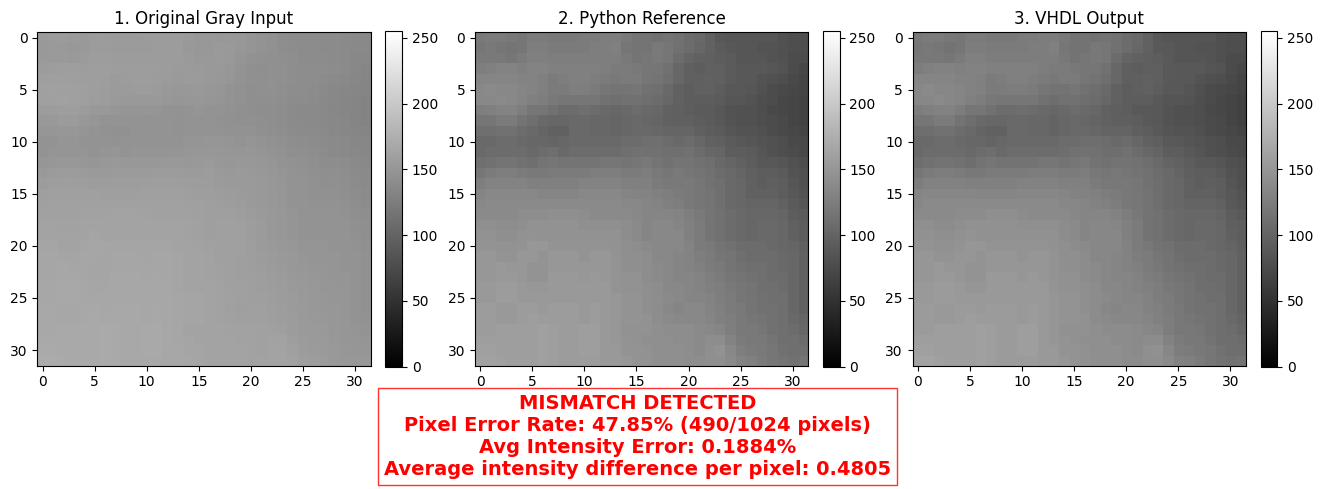

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIGURATION ----------------
CLAHE_CLIP_LIMIT = 10
PATCH_SIZE_X = 32
PATCH_SIZE_Y = 32
# -----------------------------------------------

def CLAHE_mappings_python(img_in, hist_mapping_inout):
    """
    Python implementation of the VHDL logic
    """
    # 1. Initialize
    excess = 0
    hist_mapping_inout.fill(0)

    # 2. Calculate Histogram with Clipping
    limit_threshold = CLAHE_CLIP_LIMIT - 2
    
    for y in range(PATCH_SIZE_Y):
        for x in range(PATCH_SIZE_X):
            pixel = img_in[y, x]
            if hist_mapping_inout[pixel] >= limit_threshold:
                excess += 1
            else:
                hist_mapping_inout[pixel] += 1

    # 3. Redistribute Excess
    redist = excess // 256
    hist_mapping_inout += redist 

    # 4. Calculate CDF (Mapping)
    s = 0
    total_pixels = PATCH_SIZE_X * PATCH_SIZE_Y
    
    mapping_result = np.zeros(256, dtype=np.uint8)
    
    for i in range(256):
        s += hist_mapping_inout[i]
        # Normalize: s * 256 / 1024  => s / 4
        s_normed = (s * 256) // total_pixels
        mapping_result[i] = np.clip(s_normed, 0, 255)
        
    return mapping_result

def main():
    try:
        # --- 1. Load & Clean Data ---
        try:
            # Try loading the clean file first, if it exists
            raw_data = np.loadtxt("gray_o_clean.txt")
            gray_clean = raw_data.flatten().astype(np.uint8).reshape((32, 32))
        except:
            try:
                # Fallback to original messy file
                raw_data = np.loadtxt("gray_o.txt")
                gray_clean = raw_data.flatten().astype(np.uint8).reshape((32, 32))
            except:
                print("Could not find gray_o.txt. Generating dummy gradient...")
                gray_clean = np.array([i % 256 for i in range(1024)]).reshape((32,32)).astype(np.uint8)

        # Load the VHDL output
        try:
            vhdl_out_data = np.loadtxt("clahe_output_image.txt", dtype=int)
            vhdl_result = vhdl_out_data.reshape((32, 32))
        except Exception as e:
            print(f"Error loading VHDL output: {e}")
            vhdl_result = np.zeros((32, 32))

        # --- 2. Run Python Implementation ---
        hist_scratch = np.zeros(256, dtype=np.uint8)
        mapping_table = CLAHE_mappings_python(gray_clean, hist_scratch)
        python_result = mapping_table[gray_clean]

        # --- 3. Calculate Mismatch Statistics ---
        # Calculate absolute difference map
        diff = np.abs(python_result.astype(int) - vhdl_result.astype(int)) # calculate per pixel difference
        
        # Metric A: Pixel Error Rate (% of pixels that are wrong)
        total_pixels = gray_clean.size
        mismatched_pixels = np.count_nonzero(diff)
        pixel_error_rate = (mismatched_pixels / total_pixels) * 100.0

        # Metric B: Average Intensity Error (% difference relative to 255)
        mean_abs_error = np.mean(diff) # calculate average per pixel difference
        intensity_error_percent = (mean_abs_error / 255.0) * 100.0 # calculate per pixel difference as percentage of 255

        # --- 4. Visualization ---
        fig, axes = plt.subplots(1, 3, figsize=(16, 6))

        # Image 1: Original
        ax1 = axes[0]
        im1 = ax1.imshow(gray_clean, cmap='gray', vmin=0, vmax=255)
        ax1.set_title("1. Original Gray Input")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Image 2: Python Result
        ax2 = axes[1]
        im2 = ax2.imshow(python_result, cmap='gray', vmin=0, vmax=255)
        ax2.set_title("2. Python Reference")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

        # Image 3: VHDL Result
        ax3 = axes[2]
        im3 = ax3.imshow(vhdl_result, cmap='gray', vmin=0, vmax=255)
        ax3.set_title("3. VHDL Output")
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        
        # --- 5. Display Stats ---
        if mismatched_pixels == 0:
            status_color = "green"
            status_text = "PERFECT MATCH (0% Error)"
        else:
            status_color = "red"
            status_text = (f"MISMATCH DETECTED\n"
                           f"Pixel Error Rate: {pixel_error_rate:.2f}% ({mismatched_pixels}/{total_pixels} pixels)\n"
                           f"Avg Intensity Error: {intensity_error_percent:.4f}%\n"
                           f"Average intensity difference per pixel: {mean_abs_error:.4f}")

        plt.figtext(0.5, 0.08, status_text, ha="center", fontsize=14, 
                    color=status_color, weight="bold", 
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor=status_color))

        plt.subplots_adjust(bottom=0.2) # Make room for text
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()